# RFUAV Experiment 3 — Noisy Drone RF Signal Classification

This notebook is a cleaned and checked Colab workflow for the **Kaggle Noisy Drone RF Signal Classification** dataset.

Main goals:

1. Check GPU, RAM, and disk space.
2. Download the Kaggle dataset safely.
3. Load the large `dataset.pt` file with `mmap=True` so Colab RAM does not crash.
4. Create a balanced 7-class subset.
5. Train a **small 2D CNN** on `x_spec` tensors.
6. Evaluate with accuracy, macro F1, confusion matrix, and accuracy by SNR.

## 1. Check GPU, RAM, and disk

Use this first to confirm whether Colab has a GPU and enough disk/RAM.


In [1]:
import os
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime → Change runtime type → GPU.")

print("\nRAM:")
!free -h

print("\nDisk:")
!df -h /content


CUDA available: True
GPU: Tesla T4

RAM:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.0Gi       7.5Gi       2.0Mi       4.2Gi        11Gi
Swap:             0B          0B          0B

Disk:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /


## 2. Install Kaggle package

The `!` symbol runs a Linux shell command inside Colab.


In [2]:
!pip install -q kaggle

## 3. Set up Kaggle credentials safely

Run this cell and paste your Kaggle username and API key when prompted.

Do **not** write your key directly into the notebook.


In [3]:
import os
import getpass

os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ")
os.environ["KAGGLE_KEY"] = getpass.getpass("Kaggle API key: ")

print("Kaggle credentials set for this Colab session only.")


Kaggle username: tunganhnguyen25
Kaggle API key: ··········
Kaggle credentials set for this Colab session only.


## 4. Test Kaggle access


In [4]:
!kaggle datasets list -s "noisy drone rf signal classification"


ref                                                     title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------  ---------------------------------------------  ------------  --------------------------  -------------  ---------  ---------------  
sgluege/noisy-drone-rf-signal-classification            Noisy Drone RF Signal Classification            23481212016  2023-06-08 11:41:26.823000           1377         15  0.88235295       
sgluege/noisy-drone-rf-signal-classification-v2         Noisy Drone RF Signal Classification v2        124950870773  2024-06-26 09:36:14.370000           5897          9  0.8125           
nivashne/kalman-based-leo-rf-dataset-for-uav-detection  Kalman-Based LEO RF Dataset for UAV Detection       1551916  2026-03-25 15:44:52.707000             17          1  0.5294118        
cengizhanyapcolu/dronerfattack-dataset                 

## 5. Download the smaller Noisy Drone RF dataset

This dataset is about 25 GB after extraction. Do not use the larger v2 dataset yet.


In [1]:
!rm -rf /content/noisy_drone_rf
!mkdir -p /content/noisy_drone_rf

!kaggle datasets download \
  -d sgluege/noisy-drone-rf-signal-classification \
  -p /content/noisy_drone_rf \
  --unzip \
  --force

!rm -f /content/noisy_drone_rf/noisy-drone-rf-signal-classification.zip

!ls -lh /content/noisy_drone_rf

import torch
import os

path = "/content/noisy_drone_rf/dataset.pt"

print("File size GB:", os.path.getsize(path) / 1024**3)

data = torch.load(
    path,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

print("Loaded successfully")
print(data.keys())

Dataset URL: https://www.kaggle.com/datasets/sgluege/noisy-drone-rf-signal-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 21.9G/21.9G [04:11<00:00, 93.3MB/s]

total 25G
-rw-r--r-- 1 root root 143 Jun  9 06:38 class_stats.csv
-rw-r--r-- 1 root root 25G Jun  9 06:44 dataset.pt
-rw-r--r-- 1 root root 288 Jun  9 06:38 SNR_stats.csv
File size GB: 24.099373045377433
Loaded successfully
dict_keys(['x_iq', 'x_spec', 'y', 'snr', 'duty_cycle'])


## 6. Inspect class and SNR statistics

This shows the class imbalance and SNR distribution.


In [2]:
import pandas as pd

class_stats_path = "/content/noisy_drone_rf/class_stats.csv"
snr_stats_path = "/content/noisy_drone_rf/SNR_stats.csv"

class_stats = pd.read_csv(class_stats_path)
snr_stats = pd.read_csv(snr_stats_path)

print("Class stats:")
display(class_stats)

print("SNR stats:")
display(snr_stats)


Class stats:


,Unnamed: 0,class,class_int,count
0,0,DJI,0,2194
1,1,FutabaT14,1,6938
2,2,FutabaT7,2,3661
3,3,Graupner,3,6481
4,4,Noise,4,52552
5,5,Taranis,5,16546
6,6,Turnigy,6,10333


SNR stats:


,Unnamed: 0,SNR,count
0,0,-20,3792
1,1,-18,3795
2,2,-16,3796
3,3,-14,3796
4,4,-12,3797
5,5,-10,3796
6,6,-8,3795
7,7,-6,3795
8,8,-4,3798
9,9,-2,3798


## 7. Safely load `dataset.pt` with memory mapping

`dataset.pt` is around 24–25 GB, so normal `torch.load()` can crash Colab RAM.

Always use:

```python
torch.load(path, map_location="cpu", mmap=True, weights_only=False)
```


In [3]:
import torch
import os

path = "/content/noisy_drone_rf/dataset.pt"
print("File size GB:", os.path.getsize(path) / 1024**3)

print("Before loading:")
!free -h

data = torch.load(
    path,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

print("Loaded successfully with mmap")
print("Type:", type(data))

for k, v in data.items():
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

print("After loading:")
!free -h


File size GB: 24.099373045377433
Before loading:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.5Gi       1.5Gi       2.0Mi       9.7Gi        10Gi
Swap:             0B          0B          0B
Loaded successfully with mmap
Type: <class 'dict'>
x_iq <class 'torch.Tensor'> torch.Size([98705, 2, 16384]) torch.float32
x_spec <class 'torch.Tensor'> torch.Size([98705, 2, 128, 128]) torch.float32
y <class 'torch.Tensor'> torch.Size([98705]) torch.int64
snr <class 'torch.Tensor'> torch.Size([98705]) torch.int32
duty_cycle <class 'torch.Tensor'> torch.Size([98705]) torch.float32
After loading:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.5Gi       1.5Gi       2.0Mi       9.7Gi        10Gi
Swap:             0B          0B          0B


## 8. Create a balanced 7-class subset

The full dataset is imbalanced because the `Noise` class is much larger than the smallest class.

For a fair first experiment, use:

- 1500 training samples per class
- 500 validation samples per class
- 7 classes total

Total:

- 10,500 training samples
- 3,500 validation samples


In [4]:
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

class_names = [
    "DJI",
    "FutabaT14",
    "FutabaT7",
    "Graupner",
    "Noise",
    "Taranis",
    "Turnigy"
]

y = data["y"]

train_per_class = 1500
valid_per_class = 500

train_indices = []
valid_indices = []

for cls, name in enumerate(class_names):
    cls_indices = torch.where(y == cls)[0].cpu().numpy()
    np.random.shuffle(cls_indices)

    needed = train_per_class + valid_per_class
    if len(cls_indices) < needed:
        raise ValueError(f"Class {name} has only {len(cls_indices)} samples, but {needed} are needed.")

    train_indices.extend(cls_indices[:train_per_class])
    valid_indices.extend(cls_indices[train_per_class:train_per_class + valid_per_class])

train_indices = np.array(train_indices)
valid_indices = np.array(valid_indices)

np.random.shuffle(train_indices)
np.random.shuffle(valid_indices)

print("Train samples:", len(train_indices))
print("Valid samples:", len(valid_indices))

for cls, name in enumerate(class_names):
    train_count = int((y[train_indices] == cls).sum().item())
    valid_count = int((y[valid_indices] == cls).sum().item())
    print(f"{name}: train={train_count}, valid={valid_count}")


Train samples: 10500
Valid samples: 3500
DJI: train=1500, valid=500
FutabaT14: train=1500, valid=500
FutabaT7: train=1500, valid=500
Graupner: train=1500, valid=500
Noise: train=1500, valid=500
Taranis: train=1500, valid=500
Turnigy: train=1500, valid=500


## 9. Build a PyTorch Dataset and DataLoader for `x_spec`

`x_spec` has shape:

```text
[number_of_samples, 2, 128, 128]
```

So the CNN input channel count must be `2`.


In [5]:
from torch.utils.data import Dataset, DataLoader

class NoisyDroneSpecDataset(Dataset):
    def __init__(self, data, indices):
        self.x_spec = data["x_spec"]
        self.y = data["y"]
        self.snr = data["snr"]
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        x = self.x_spec[real_idx]   # [2, 128, 128]
        label = self.y[real_idx]
        snr = self.snr[real_idx]
        return x, label, snr

batch_size = 64
num_workers = 0  # Safer for Colab + memory-mapped tensors
pin_memory = torch.cuda.is_available()

train_dataset = NoisyDroneSpecDataset(data, train_indices)
valid_dataset = NoisyDroneSpecDataset(data, valid_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

x_batch, y_batch, snr_batch = next(iter(train_loader))
print("x batch:", x_batch.shape)
print("y batch:", y_batch.shape)
print("snr batch:", snr_batch.shape)
print("x dtype:", x_batch.dtype)
print("y dtype:", y_batch.dtype)
print("snr dtype:", snr_batch.dtype)


x batch: torch.Size([64, 2, 128, 128])
y batch: torch.Size([64])
snr batch: torch.Size([64])
x dtype: torch.float32
y dtype: torch.int64
snr dtype: torch.int32


## 10. Define a small 2D CNN

This model is intentionally small so it trains quickly on Colab.

Input:

```text
[batch, 2, 128, 128]
```

Output:

```text
[batch, 7]
```


In [6]:
import torch.nn as nn

class SmallSpecCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)

model_test = SmallSpecCNN(num_classes=7)
with torch.no_grad():
    out = model_test(x_batch[:2])
print("Test output shape:", out.shape)


Test output shape: torch.Size([2, 7])


## 11. Mount Google Drive for saving results

This cell is optional but recommended. If Drive is not mounted, results are saved in `/content/noisy_drone_results`.


In [7]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive/RFUAV_Project/models/noisy_drone_spec_cnn_balanced"
except Exception as e:
    print("Drive mount failed or not available:", e)
    SAVE_DIR = "/content/noisy_drone_results/noisy_drone_spec_cnn_balanced"

os.makedirs(SAVE_DIR, exist_ok=True)
print("Save directory:", SAVE_DIR)


Mounted at /content/drive
Save directory: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_spec_cnn_balanced


## 12. Train the CNN

This trains on the balanced subset and saves:

- `best.pt`
- `last.pt`
- `history.csv`


In [9]:
import torch.optim as optim
from tqdm import tqdm
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SmallSpecCNN(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
history = []
best_acc = 0.0

for epoch in range(epochs):
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{epochs}")

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, labels, snrs in tqdm(train_loader, desc="Training"):
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for x, labels, snrs in tqdm(valid_loader, desc="Validation"):
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Acc : {valid_acc:.4f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
    })

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best.pt"))
        print("Saved best model.")

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "last.pt"))
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(SAVE_DIR, "history.csv"), index=False)

print("Finished.")
print("Best valid accuracy:", best_acc)
print("Saved to:", SAVE_DIR)


Using device: cuda
Epoch 1/20


Validation: 100%|██████████| 55/55 [00:00<00:00, 59.51it/s]


Train Loss: 1.5691
Train Acc : 0.4016
Valid Loss: 1.4259
Valid Acc : 0.5211
Saved best model.
Epoch 2/20


Validation: 100%|██████████| 55/55 [00:00<00:00, 62.35it/s]


Train Loss: 1.2580
Train Acc : 0.5600
Valid Loss: 1.2637
Valid Acc : 0.5529
Saved best model.
Epoch 3/20


...

Train Loss: 0.6201
Train Acc : 0.7947
Valid Loss: 0.8362
Valid Acc : 0.6729
Epoch 19/20


Validation: 100%|██████████| 55/55 [00:00<00:00, 60.55it/s]


Train Loss: 0.6377
Train Acc : 0.7909
Valid Loss: 0.6560
Valid Acc : 0.7906
Saved best model.
Epoch 20/20


Validation: 100%|██████████| 55/55 [00:00<00:00, 61.90it/s]

Train Loss: 0.5758
Train Acc : 0.8117
Valid Loss: 0.6407
Valid Acc : 0.7914
Saved best model.
Finished.
Best valid accuracy: 0.7914285714285715
Saved to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_spec_cnn_balanced


## 13. Plot training curves


,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,1.569118,0.401619,1.425855,0.521143
1,2,1.258042,0.560000,1.263740,0.552857
2,3,1.101980,0.632095,1.059348,0.615143
3,4,1.014294,0.658095,1.132343,0.551714
4,5,0.922502,0.695714,0.981099,0.640571
5,6,0.849121,0.721143,1.003481,0.640571
6,7,0.860178,0.714952,1.304273,0.624286
7,8,0.807186,0.732286,0.927726,0.633429
8,9,0.778001,0.739143,2.111050,0.431429
9,10,0.781534,0.742762,0.767934,0.745429


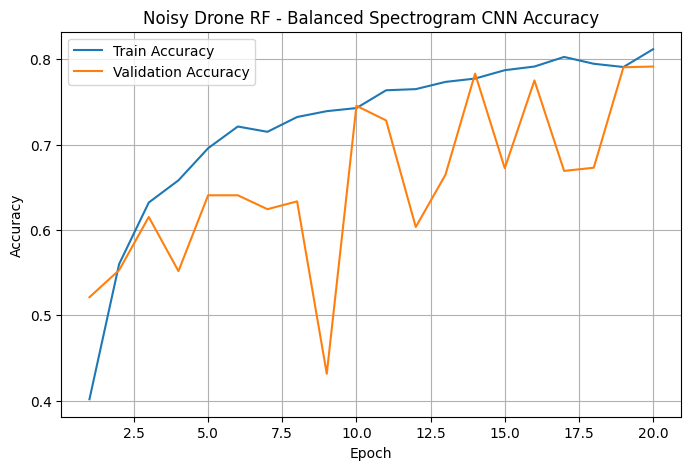

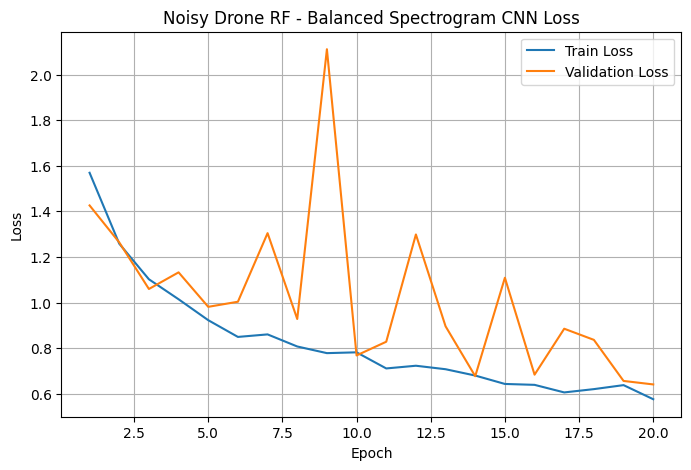

In [10]:
import matplotlib.pyplot as plt

history_path = os.path.join(SAVE_DIR, "history.csv")
history_df = pd.read_csv(history_path)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Loss")
plt.legend()
plt.grid(True)
plt.show()


## 14. Classification report and confusion matrix

Use macro F1 because this dataset is naturally imbalanced, even though this first subset is balanced.


Loaded best model: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_spec_cnn_balanced/best.pt
              precision    recall  f1-score   support

         DJI       0.79      0.81      0.80       500
   FutabaT14       0.95      0.75      0.84       500
    FutabaT7       1.00      0.72      0.84       500
    Graupner       1.00      0.81      0.89       500
       Noise       0.46      0.94      0.62       500
     Taranis       1.00      0.83      0.91       500
     Turnigy       0.86      0.69      0.77       500

    accuracy                           0.79      3500
   macro avg       0.86      0.79      0.81      3500
weighted avg       0.86      0.79      0.81      3500



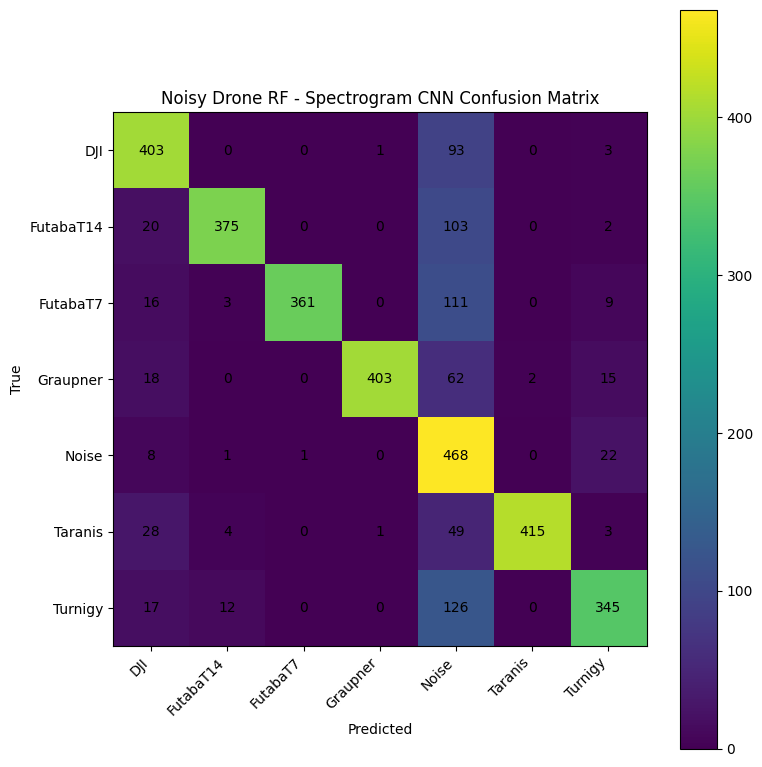

Saved confusion matrix to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_spec_cnn_balanced/confusion_matrix.png


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model before evaluation
best_path = os.path.join(SAVE_DIR, "best.pt")
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device))
    print("Loaded best model:", best_path)

model.eval()
all_preds = []
all_labels = []
all_snrs = []

with torch.no_grad():
    for x, labels, snrs in valid_loader:
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_snrs.extend(snrs.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Noisy Drone RF - Spectrogram CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200)
plt.show()
print("Saved confusion matrix to:", cm_path)


## 15. Accuracy by SNR

This is one of the most important analyses for this dataset.

Low SNR values like `-20 dB` should be harder. High SNR values like `20 dB` to `30 dB` should be easier.


,SNR,accuracy
0,-20,0.088000
1,-18,0.223140
2,-16,0.191176
3,-14,0.288889
4,-12,0.443662
5,-10,0.567797
6,-8,0.702290
7,-6,0.874074
8,-4,0.897260
9,-2,0.925170


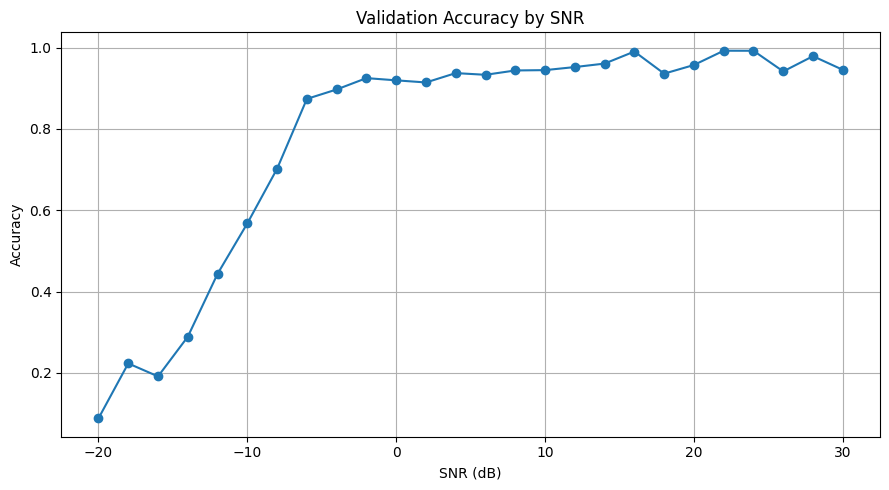

Saved SNR accuracy plot to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_spec_cnn_balanced/accuracy_by_snr.png


In [12]:
results_df = pd.DataFrame({
    "label": all_labels,
    "pred": all_preds,
    "snr": all_snrs,
})
results_df["correct"] = results_df["label"] == results_df["pred"]

snr_acc = results_df.groupby("snr")["correct"].mean().reset_index()
snr_acc.columns = ["SNR", "accuracy"]
display(snr_acc)

plt.figure(figsize=(9, 5))
plt.plot(snr_acc["SNR"], snr_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()
snr_path = os.path.join(SAVE_DIR, "accuracy_by_snr.png")
plt.savefig(snr_path, dpi=200)
plt.show()
print("Saved SNR accuracy plot to:", snr_path)
